## Audio Generator

In [4]:
import signalcomparison as sc

In [5]:
import os
import re
import numpy as np
import pandas as pd
import soundfile as sf
from IPython.display import Audio

import rich
import matplotlib.pyplot as plt
import seaborn as sns
from ast import literal_eval

In [6]:
DEFAULT_FS = 48000

In [7]:
class TestToneEvalClass:
    def __init__(self, duration, samplerate, frequency, level, filefold):
        """
        frequency: float or list/array of floats (Hz)
        level: float or list/array of floats (same length as frequency if list)
        """
        self.samplerate = samplerate
        self.frequency = frequency
        self.duration = duration
        self.filefold = filefold
        self.level = level
    
    def SinWaveGenerator(self):
        """
        Generate single- or multi-frequency sine wave.
        - If self.frequency is a scalar -> single tone
        - If self.frequency is list/array -> sum of tones
        """
        t = np.linspace(0, self.duration, int(self.duration * self.samplerate), endpoint=False)

        # --- Single-tone case ---
        if np.isscalar(self.frequency):
            return self.level * np.sin(2 * np.pi * self.frequency * t)

        # --- Multi-tone case ---
        freqs = np.asarray(self.frequency, dtype=float)

        # Levels: either scalar (same for all) or list per frequency
        if np.isscalar(self.level):
            levels = np.full_like(freqs, float(self.level))
        else:
            levels = np.asarray(self.level, dtype=float)
            if levels.shape != freqs.shape:
                raise ValueError("level must be scalar or same length as frequency list")

        # Shape: (n_freq, n_samples)
        t_2d = t[np.newaxis, :]                  # (1, N)
        freqs_2d = freqs[:, np.newaxis]         # (K, 1)
        levels_2d = levels[:, np.newaxis]       # (K, 1)

        # Sum all tones
        signal = np.sum(levels_2d * np.sin(2 * np.pi * freqs_2d * t_2d), axis=0)

        # Optional normalisation to avoid clipping
        max_abs = np.max(np.abs(signal))
        if max_abs > 0:
            signal = signal / max_abs

        return signal

    def PlotTimeSignal(self, data):
        # use self.duration instead of undefined 'duration'
        time = np.linspace(0., self.duration, len(data))
        plt.figure(figsize=(10, 4))
        plt.plot(time, data, label="Waveform")
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude')
        plt.ylim(-1.1, 1.1)
        plt.title('Waveform of the Audio')
        plt.grid(True)
        plt.legend(loc="upper right")
        plt.show()

    def PlotFFT(self,data):
        data = data / np.max(np.abs(data))
        window = np.hanning(len(data))  
        y_windowed = data * window  
        
        # Zero-pad to increase FFT resolution
        #N = 2**16  # Larger FFT size (e.g., 16384)
        fft_result = np.fft.fft(y_windowed, n=len(data))
        frequencies = np.fft.fftfreq(len(data), d=1/self.samplerate)
        
        # Keep only the positive half of the spectrum
        half_N = len(data) // 2
        fft_magnitude = np.abs(fft_result[:half_N]) / len(data)
        fft_magnitude_db = 20 * np.log10(fft_magnitude + 1e-10)
        frequencies = frequencies[:half_N]
        
        # Plot FFT with log scale
        plt.figure(figsize=(12, 4),dpi=96)
        plt.plot(frequencies, fft_magnitude_db, color='b')
        plt.xscale("log")  # Logarithmic frequency axis
        plt.xlabel("Frequency (Hz)", fontsize=14)
        plt.ylabel("Magnitude (dB)", fontsize=14)
#        plt.title("Enhanced FFT Spectrum (Log Scale)", fontsize=16)
        plt.grid()
        plt.ylim(-100, 0)
        plt.show()
        
    def SignalFileGenerator(self, audiodata, filename):
        ##by default all the data will be nomalized
        Normalize_Transform = Normalize(p=1.0)
        audiodata = Normalize_Transform(audiodata,self.samplerate)
#        write(self.filefold+filename, self.samplerate, audiodata)
        sf.write(self.filefold+filename, audiodata, self.samplerate, subtype='PCM_16')
        return self.filefold+filename

    def Mp3MixingFileGenerator(self,audiodata,filename,bitrate=64):
        #the single file set to LUFS -14
        Lufs_Transform = LoudnessNormalization(min_lufs=-14.0,max_lufs=-14.0,p=1.0)
        mixing_data = Lufs_Transform(audiodata, self.samplerate)
        tmp_file = self.SignalFileGenerator(mixing_data, filename)
        command_out = os.popen("sh ./Audio_LameCompress.sh -a %s -b %s " %(tmp_file,bitrate)).read()
        match = re.search(r"outputMp3toWavfilepath=\s*(.+?)\s+by FFMPEG", command_out)
        if match:
            file_path = match.group(1)  # Capture the file path
            return file_path
        else:
            print("File path not found in the output.") 
            return "File path not found in the output."

In [8]:
test = TestToneEvalClass(duration=8.0, samplerate=48000,
                         frequency=[100, 500,800, 1000, 2000,5000],
                         level=[0.5, 0.5, 0.8, 0.5, 0.8, 0.6],        # per tone
                         filefold="./Experiment.A.Audio/")
x = test.SinWaveGenerator()

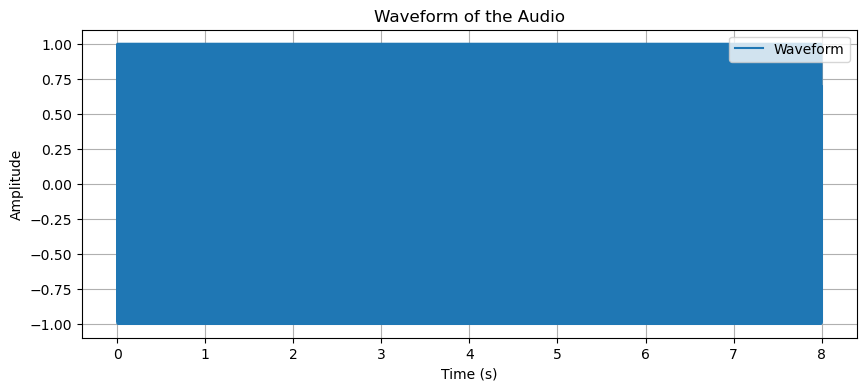

In [9]:
test.PlotTimeSignal(x)

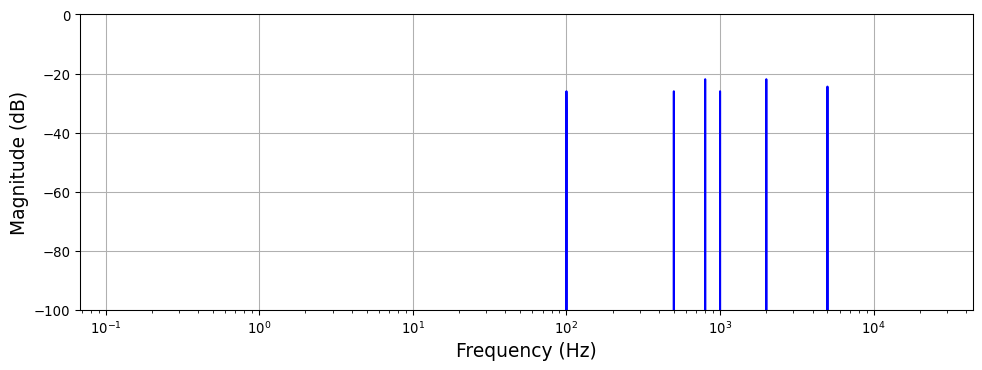

In [10]:
test.PlotFFT(x)

In [11]:
TestToneFiLE = test.SignalFileGenerator(x,f"TestTone_testtone_8s.wav" )

/root/anaconda3/envs/codecbreak/lib/python3.10/site-packages/audiomentations/core/transforms_interface.py:107: UserWarning: Warning: input samples dtype is np.float64. Converting to np.float32
  warnings.warn(


In [12]:
TestToneFiLE

'./Experiment.A.Audio/TestTone_testtone_8s.wav'